(jv)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`工作搜寻 VII：在职搜索 <single: Job Search VII: On-the-Job Search>`

```{index} single: Models; On-the-Job Search
```

```{contents} 目录
:depth: 2
```

```{include} _admonition/gpu.md
```

除了 Anaconda 中已有的库之外，本讲座还需要以下库：

In [1]:
!pip install jax

## 概述

在本节中，我们将解决一个简单的在职搜索模型

* 本讲基于 {cite}`Ljungqvist2012` 的练习 6.18 和 {cite}`Jovanovic1979`

让我们从一些导入开始：

In [2]:
from typing import NamedTuple

import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC', 'DejaVu Sans']
import scipy.stats as stats
import jax
import jax.numpy as jnp
import jax.random as jr

### 模型特点

```{index} single: On-the-Job Search; Model Features
```

* 模型结合了在职搜索和工作岗位特定的人力资本积累
* 这是一个包含一个状态变量和两个控制变量的无限期动态规划问题

## 模型

```{index} single: On-the-Job Search; Model
```

设 $x_t$ 为劳动者在当前公司和工作岗位的人力资本水平，$w_t$ 为其当前工资。

工资由以下公式决定：$w_t = x_t(1 - s_t - \phi_t)$，其中

* $\phi_t$ 表示劳动者在当前岗位为提高人力资本而付出的投资
* $s_t$ 表示用于从其他公司获得新工作机会的搜索努力

只要劳动者继续留在当前工作，$\{x_t\}$ 的演变由 $x_{t+1} = g(x_t, \phi_t)$ 给出。

当 $t$ 时刻的搜索努力为 $s_t$ 时，劳动者以概率 $\pi(s_t) \in [0, 1]$ 得到新的工作机会。

这个机会的价值（以工作岗位特定人力资本衡量）是 $u_{t+1}$，其中 $\{u_t\}$ 是具有共同分布 $f$ 的独立同分布序列。

劳动者可以拒绝当前的工作机会并继续现有的工作。

因此，若劳动者接受了新的工作机会，则$x_{t+1} = u_{t+1}$，否则 $x_{t+1} = g(x_t, \phi_t)$。

令 $b_{t+1} \in \{0,1\}$ 为二元随机变量，其中 $b_{t+1} = 1$ 表示劳动者在时间 $t$ 结束时收到一个工作机会。

我们可以写成

```{math}
:label: jd

x_{t+1}
= (1 - b_{t+1}) g(x_t, \phi_t) + b_{t+1}
    \max \{ g(x_t, \phi_t), u_{t+1}\}
```

主体的目标：通过控制变量 $\{s_t\}$ 和 $\{\phi_t\}$ 来最大化预期折现工资总和。

对 $v(x_{t+1})$ 取期望并使用 {eq}`jd`，
这个问题的贝尔曼方程可以写成

```{math}
:label: jvbell

v(x)
= \max_{s + \phi \leq 1}
    \left\{
        x (1 - s - \phi) + \beta (1 - \pi(s)) v[g(x, \phi)] +
        \beta \pi(s) \int v[g(x, \phi) \vee u] f(du)
     \right\}
```

这里默认 $s$ 和 $\phi$ 非负，而
$a \vee b := \max\{a, b\}$。

### 参数化

```{index} single: On-the-Job Search; 参数化
```

在下面的实现中，我们将聚焦于以下参数化设定

$$
g(x, \phi) = A (x \phi)^{\alpha},
\quad
\pi(s) = \sqrt s
\quad \text{和} \quad
f = \text{Beta}(2, 2)
$$

默认参数值为

* $A = 1.4$
* $\alpha = 0.6$
* $\beta = 0.96$

$\text{Beta}(2,2)$ 分布的支撑集是 $(0,1)$ - 它具有单峰、对称的密度函数，峰值在0.5。

(jvboecalc)=
### 粗略计算

在求解模型之前，让我们先做一些简单的计算，帮助我们直观理解模型的解。

我们可以看到，劳动者有两种途径来积累资本并提高工资：

1. 通过 $\phi$ 投资于当前工作岗位特定的人力资本
1. 通过 $s$ 搜寻更匹配岗位特定人力资本的新工作

由于工资是 $x (1 - s - \phi)$，通过 $\phi$ 或 $s$ 进行投资的边际成本是相同的。

我们的风险中性劳动者应该专注于预期回报最高的方式。

相对预期回报将取决于$x$。

例如，假设$x = 0.05$

* 如果$s=1$且$\phi = 0$，由于$g(x,\phi) = 0$，
  对{eq}`jd`取期望值得到下一期的预期资本等于$\pi(s) \mathbb{E} u
  = \mathbb{E} u = 0.5$。
* 如果$s=0$且$\phi=1$，那么下一期资本是$g(x, \phi) = g(0.05, 1) \approx 0.23$。

两种回报率都不错，但搜索的回报更好。

接下来，假设$x = 0.4$

* 如果$s=1$且$\phi = 0$，那么下一期的预期资本仍然是$0.5$
* 如果$s=0$且$\phi = 1$，那么$g(x, \phi) = g(0.4, 1) \approx 0.8$

在这种情况下，投资于岗位特定人力资本的回报高于搜索新工作的预期回报。

综合这些观察，我们得到两个非正式的预测：

1. 在任何给定状态$x$下，两个控制变量$\phi$和$s$主要呈现替代关系 --- 且劳动者会专注于预期回报较高的工具。
1. 对于足够小的 $x$，工作搜寻将优于岗位特定人力资本投资。而当$x$值较大时，结论则相反。

现在让我们转向模型实现，并验证是否与预测结果一致。

## 模型实现

```{index} single: On-the-Job Search; Programming Implementation
```

我们使用 [JAX](https://docs.jax.dev/) 来求解模型，使用一个 `NamedTuple` 来保存参数和网格。

In [3]:
class JVWorker(NamedTuple):
    A: float                # g中的规模参数
    α: float                # g中的曲率参数
    β: float                # 折现因子
    x_grid: jnp.ndarray     # 人力资本值的网格
    s_grid: jnp.ndarray     # 搜索努力值的网格
    ϕ_grid: jnp.ndarray     # 投资值的网格
    f_rvs: jnp.ndarray      # 来自f的抽样，用于蒙特卡洛积分


def create_jv_worker(A=1.4,               # g中的规模参数
                     α=0.6,               # g中的曲率参数
                     β=0.96,              # 折现因子
                     a=2,                 # f的参数
                     b=2,                 # f的参数
                     grid_size=50,        # 状态网格的大小
                     mc_size=100,         # f的抽样数量
                     search_grid_size=15, # 每个行动网格的大小
                     ɛ=1e-4,
                     seed=1234):
    """
    创建一个在职搜索模型的实例。
    """
    f_rvs = jr.beta(jr.key(seed), a, b, (mc_size,))

    # 网格的最大值是f的大分位数值和固定点y = g(y, 1)的最大值
    grid_max = max(A**(1 / (1 - α)), stats.beta(a, b).ppf(1 - ɛ))

    x_grid = jnp.linspace(ɛ, grid_max, grid_size)
    s_grid = jnp.linspace(ɛ, 1, search_grid_size)
    ϕ_grid = jnp.linspace(ɛ, 1, search_grid_size)

    return JVWorker(A=A, α=α, β=β, x_grid=x_grid, s_grid=s_grid,
                    ϕ_grid=ϕ_grid, f_rvs=f_rvs)

以下是转移函数 $g$ 和获得工作机会的概率 $\pi$。

In [4]:
@jax.jit
def g(jv, x, ϕ):
    "工作岗位特定人力资本的转移函数。"
    return jv.A * (x * ϕ)**jv.α


@jax.jit
def π(s):
    "搜索努力为s时获得工作机会的概率。"
    return jnp.sqrt(s)

接下来，我们在最大化之前写出贝尔曼方程 {eq}`jvbell` 的右侧：

```{math}
:label: defw

B(x, s, \phi)
 := x (1 - s - \phi) + \beta (1 - \pi(s)) v[g(x, \phi)] +
         \beta \pi(s) \int v[g(x, \phi) \vee u] f(du)
```

我们用一个数组来表示$v$，该数组给出$v$在`x_grid`上的值，并通过线性插值从中恢复出一个函数。

积分被替换为对`f_rvs`中抽样值的蒙特卡洛平均。

下面的函数是针对**单个**状态 $x$ 和**单个**行动对 $(s, \phi)$ 编写的 --- 所以它读起来很像{eq}`defw`本身。

In [5]:
def _B(v, jv, x, s, ϕ):
    """
    贝尔曼方程在最大化之前的右侧，针对单个状态x和单个行动对(s, ϕ)。

    不可行的组合（即s + ϕ > 1的情形）被赋值为-∞，
    因此它们永远不会被最大化步骤选中。
    """
    v_func = lambda z: jnp.interp(z, jv.x_grid, v)
    gxϕ = g(jv, x, ϕ)

    # ∫ v[g(x, ϕ) ∨ u] f(du) 的蒙特卡洛估计
    integral = jnp.mean(v_func(jnp.maximum(gxϕ, jv.f_rvs)))

    q = π(s) * integral + (1 - π(s)) * v_func(gxϕ)
    return jnp.where(s + ϕ <= 1, x * (1 - s - ϕ) + jv.β * q, -jnp.inf)

现在我们在状态和行动的每一种组合上评估`_B`。

我们不写三重嵌套循环，而是三次应用`jax.vmap`。

每次应用都针对一个参数进行向量化，因此下面的堆叠相当于扮演了三重循环的角色 --- 但整个过程编译为可以并行运行的代码。

在`in_axes`中，`0`标记了被映射的参数，而`None`则表示该参数保持固定。

In [6]:
# _B的参数顺序是    (v,    jv,   x,    s,    ϕ)
_B_ϕ   = jax.vmap(_B,    in_axes=(None, None, None, None, 0))     # 对ϕ
_B_sϕ  = jax.vmap(_B_ϕ,  in_axes=(None, None, None, 0,    None))  # 然后对s
_B_xsϕ = jax.vmap(_B_sϕ, in_axes=(None, None, 0,    None, None))  # 然后对x

结果是$B$的完全向量化版本。

In [7]:
@jax.jit
def B(v, jv):
    """
    在每一种(状态, 行动)组合上评估B。

    返回一个形状为(len(x_grid), len(s_grid), len(ϕ_grid))的数组，其中
    条目[i, j, k]保存了在状态x_i下选择(s_j, ϕ_k)的值。
    """
    return _B_xsϕ(v, jv, jv.x_grid, jv.s_grid, jv.ϕ_grid)

有了`B`，贝尔曼算子和贪婪策略都只需一行代码
--- 我们在两个行动坐标轴上进行最大化，一种情况下取最大值，另一种情况下取最大化点。

In [8]:
@jax.jit
def T(v, jv):
    "贝尔曼算子。"
    return jnp.max(B(v, jv), axis=(1, 2))


@jax.jit
def get_greedy(v, jv):
    "计算v-贪婪策略，以一对(s_policy, ϕ_policy)的形式返回。"
    vals = B(v, jv)

    # 将两个行动坐标轴展平，这样单个argmax就能在每个状态下选出最佳
    # 组合，然后将展平后的索引转换回(s, ϕ)对
    n_s, n_ϕ = len(jv.s_grid), len(jv.ϕ_grid)
    best = jnp.argmax(vals.reshape(len(jv.x_grid), n_s * n_ϕ), axis=1)
    j, k = jnp.unravel_index(best, (n_s, n_ϕ))

    return jv.s_grid[j], jv.ϕ_grid[k]

为了求解模型，我们迭代$T$直至收敛。

我们使用`jax.lax.while_loop`，以便整个迭代过程编译成单一操作，并限制迭代步数以确保循环总能终止。

In [9]:
@jax.jit
def solve_model(jv, tol=1e-4, max_iter=1_000):
    """
    通过值函数迭代求解模型。

    返回值函数、所用的迭代次数以及最终误差，以便调用者检查是否收敛。
    """
    def condition(loop_state):
        i, v, error = loop_state
        return (error > tol) & (i < max_iter)

    def update(loop_state):
        i, v, error = loop_state
        v_new = T(v, jv)
        return i + 1, v_new, jnp.max(jnp.abs(v_new - v))

    v_init = jv.x_grid * 0.5
    i, v, error = jax.lax.while_loop(condition, update, (0, v_init, tol + 1))
    return v, i, error

```{note}
这里的网格较小，这个模型在NumPy中也能运行得很好。

我们使用JAX，是因为这段代码几乎和对应的NumPy代码一样可读，
同时又具有更好的可扩展性 --- 可以扩展到更精细的网格，或者带有额外状态变量的更丰富的模型版本，
在这些情况下，同样的代码将能够充分利用GPU。
```

## 策略求解

```{index} single: On-the-Job Search; Solving for Policies
```

让我们生成最优政策并看看它们是什么样子。

(jv_policies)=

In [10]:
jv = create_jv_worker()
v_star, num_iter, error = solve_model(jv)
s_star, ϕ_star = get_greedy(v_star, jv)

print(f"经过{num_iter}次迭代收敛，误差为{error:.2e}。")

经过205次迭代收敛，误差为9.82e-05。


我们绘制以下图表：

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


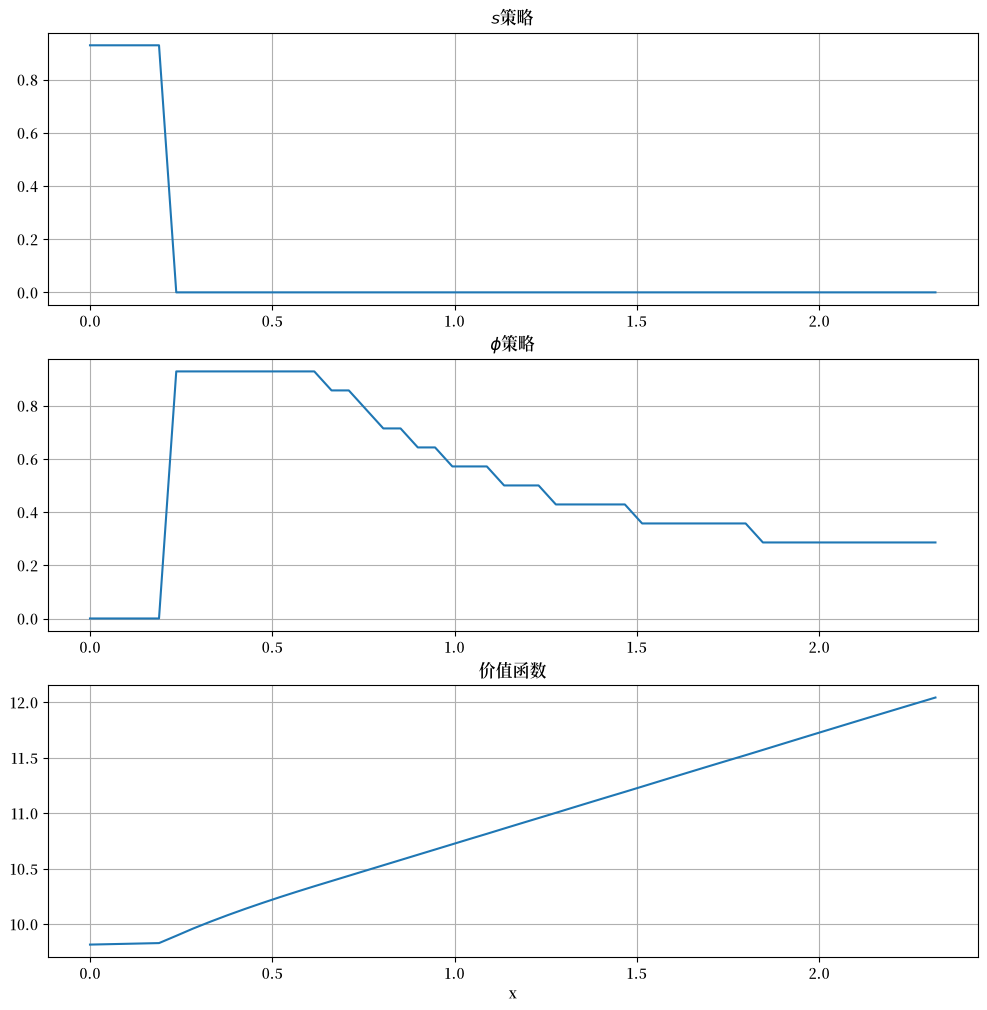

In [11]:
plots = [s_star, ϕ_star, v_star]
titles = [r"$s$策略", r"$\phi$策略",  "价值函数"]

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, plot, title in zip(axes, plots, titles):
    ax.plot(jv.x_grid, plot)
    ax.set(title=title)
    ax.grid()

axes[-1].set_xlabel("x")
plt.show()

横轴表示状态变量 $x$，纵轴表示 $s(x)$ 和 $\phi(x)$。

总的来说，这些策略与我们在{ref}`上文<jvboecalc>`中的预测相符

* 劳动者根据相对回报在两种投资策略之间切换。
* 对于较低的 $x$ 值，最佳选择是寻找新工作。
* 一旦 $x$ 变大，劳动者通过投资于当前职位的特定人力资本会获得更好的回报。

## 练习

```{exercise-start}
:label: jv_ex1
```

让我们看看与这些策略相关的状态过程 $\{x_t\}$ 的动态特征。

当根据最优策略选择 $\phi_t$ 和 $s_t$，且 $\mathbb{P}\{b_{t+1} = 1\} = \pi(s_t)$ 时，动态特征由{eq}`jd`给出。

由于动态是随机的，分析会有些微妙。

一种方法是对一个相对精细的网格（称为`plot_grid`）中的每个 $x$，绘制大量（$K$个）在给定 $x_t = x$ 条件下 $x_{t+1}$ 的实现值。

用以下方式绘制每个实现对应一个点的45度图,设置

```{code-block} ipython3
jv = create_jv_worker(grid_size=25, mc_size=50)
plot_grid_max, plot_grid_size = 1.2, 100
plot_grid = jnp.linspace(0, plot_grid_max, plot_grid_size)
fig, ax = plt.subplots()
ax.set_xlim(0, plot_grid_max)
ax.set_ylim(0, plot_grid_max)
```

通过观察图表,可以论证在最优策略下,状态 $x_t$ 将收敛到接近1的常数值 $\bar x$。

论证在稳态时, $s_t \approx 0$ 且 $\phi_t \approx 0.6$。

```{exercise-end}
```

```{solution-start} jv_ex1
:class: dropdown
```

以下是生成45度图的代码。

注意，我们一次性抽取所有的实现值，而不是在状态和抽样上循环。

findfont: Failed to find font weight normal, now using 600.


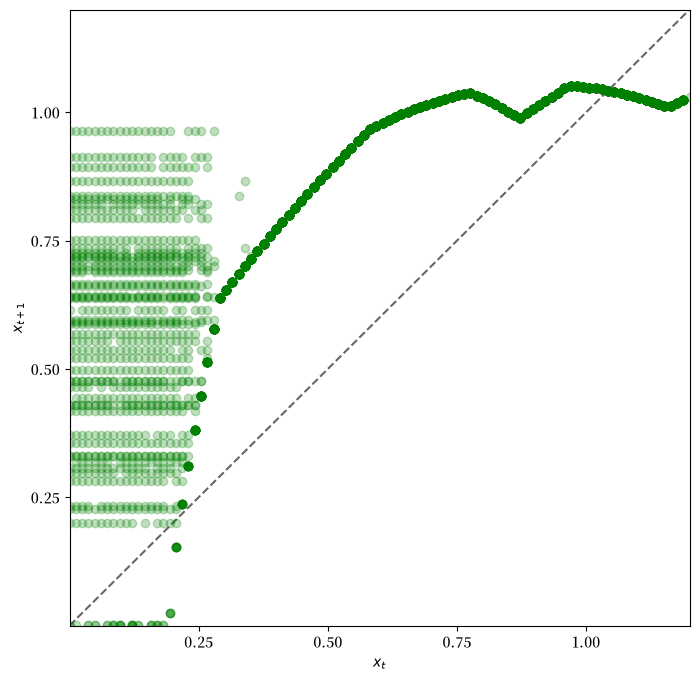

In [12]:
jv = create_jv_worker(grid_size=25, mc_size=50)
v_star, _, _ = solve_model(jv)
s_policy, ϕ_policy = get_greedy(v_star, jv)

# 将策略函数数组转换为实际函数
s = lambda y: jnp.interp(y, jv.x_grid, s_policy)
ϕ = lambda y: jnp.interp(y, jv.x_grid, ϕ_policy)

plot_grid_max, plot_grid_size = 1.2, 100
plot_grid = jnp.linspace(0, plot_grid_max, plot_grid_size)


@jax.jit
def simulate_next(key, plot_grid):
    """
    对plot_grid中的每个x，根据上面给出的x_{t+1}运动规律，抽取下一期资本的实现值。
    返回一个形状为(len(plot_grid), mc_size)的数组。
    """
    K = len(jv.f_rvs)
    gxϕ = g(jv, plot_grid, ϕ(plot_grid))[:, jnp.newaxis]   # 形状 (n, 1)
    u = jv.f_rvs[jnp.newaxis, :]                           # 形状 (1, K)

    # 工作机会以概率π(s(x))到来，在各次抽样之间相互独立
    b = jr.uniform(key, (len(plot_grid), K)) < π(s(plot_grid))[:, jnp.newaxis]

    return jnp.where(b, jnp.maximum(gxϕ, u), gxϕ)


x_next = simulate_next(jr.key(1234), plot_grid)

fig, ax = plt.subplots(figsize=(8, 8))
ticks = (0.25, 0.5, 0.75, 1.0)
ax.set(xticks=ticks, yticks=ticks,
       xlim=(0, plot_grid_max),
       ylim=(0, plot_grid_max),
       xlabel='$x_t$', ylabel='$x_{t+1}$')

ax.plot(plot_grid, plot_grid, 'k--', alpha=0.6)  # 45度线
ax.plot(jnp.repeat(plot_grid, x_next.shape[1]), x_next.ravel(),
        'go', alpha=0.25)

plt.show()

观察动态变化，我们可以看到

- 如果 $x_t$ 低于约0.2，动态变化是随机的，但
  $x_{t+1} > x_t$ 的可能性很大。
- 随着 $x_t$ 增加，动态变化变得确定性，并且
  $x_t$ 收敛到接近1的稳态值。

参考回 {ref}`这里 <jv_policies>` 的图表，我们看到 $x_t \approx 1$ 意味着
$s_t = s(x_t) \approx 0$ 且
$\phi_t = \phi(x_t) \approx 0.6$。

```{solution-end}
```


```{exercise}
:label: jv_ex2

在 {ref}`jv_ex1` 中，我们发现 $s_t$ 收敛到零，
而 $\phi_t$ 收敛到约0.6。

由于这些结果是在 $\beta$ 接近1的情况下计算的，
让我们将它们与*无限*耐心的劳动者的最佳选择进行比较。

直观地说，无限耐心的劳动者会希望最大化稳态工资，
而稳态工资是稳态资本的函数。

你可以认为这是既定事实——这确实是真的——无限耐心的劳动者
在长期内不会搜索（即，对于较大的 $t$，$s_t = 0$）。

因此，给定 $\phi$，稳态资本是映射 $x \mapsto g(x, \phi)$ 的正固定点 $x^*(\phi)$。

稳态工资可以写作 $w^*(\phi) = x^*(\phi) (1 - \phi)$。

绘制 $w^*(\phi)$ 关于 $\phi$ 的图像，并研究 $\phi$ 的最佳选择。

你能对你看到的值给出一个大致的解释吗？
```

```{solution-start} jv_ex2
:class: dropdown
```

可以用以下方法生成图像

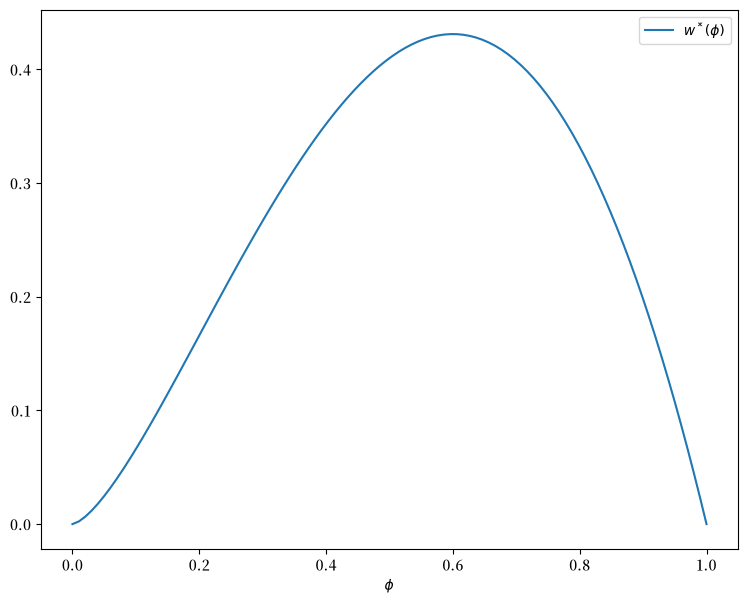

In [13]:
jv = create_jv_worker()

def xbar(ϕ):
    return (jv.A * ϕ**jv.α)**(1 / (1 - jv.α))

ϕ_grid = jnp.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(9, 7))
ax.set(xlabel=r'$\phi$')
ax.plot(ϕ_grid, xbar(ϕ_grid) * (1 - ϕ_grid), label=r'$w^*(\phi)$')
ax.legend()

plt.show()

观察到最大值约在0.6处。

这与{ref}`jv_ex1`中得到的$\phi$的长期值相似。

因此，无限耐心的劳动者的行为与$\beta = 0.96$的劳动者的行为相似。

这看起来是合理的，并且帮助我们确认我们的动态规划解可能是正确的。

```{solution-end}
```